# Análisis H/V restringido por supuestos geotécnicos

En lugar de buscar "el pico más alto", este notebook pregunta si cada curva muestra la resonancia que se espera de un **relleno de terraza sobre roca meteorizada**.

## Supuestos (declarados explícitamente)

| Supuesto | Valor | Fuente |
|---|---|---|
| Vs del relleno de terraza / coluvión | 150–350 m/s (central 250) | valores típicos de rellenos granulares compactados a mano |
| Espesor del relleno H | 1–8 m | rango arqueológico plausible; se reemplaza por la altura medida del muro cuando se tenga |
| Vs de la roca meteorizada / saprolito | ≥ 500 m/s | valor típico de saprolito |
| Modelo | capa homogénea sobre semiespacio: f0 = Vs / (4H) | aproximación de cuarto de longitud de onda |

## Consecuencias que restringen el análisis

- **Banda física de f0:** de 150/(4·8) ≈ 4.7 Hz a 350/(4·1) ≈ 87 Hz.
- **Banda instrumental útil:** el muestreo es de 200 Hz y el filtro anti-alias actúa por encima de unos 60–80 Hz, así que el pico se busca en **4.7–50 Hz**. Con Vs = 250 m/s, eso equivale a H ≈ 1.25–13 m.
- **Amplitud esperada:** el contraste de impedancia Vs_roca/Vs_relleno es ≥ 500/350 ≈ 1.4 (relleno rígido) y ≥ 500/150 ≈ 3.3 (relleno blando). Una curva con A0 < 1.4 en la banda **no** muestra el contraste supuesto.
- **Cobertura SESAME:** el criterio exige la curva entre f0/4 y 4·f0. Con fmax = 80 Hz eso solo se cumple si f0 ≤ 20 Hz, es decir, H ≥ 3 m con Vs = 250. Los picos entre 20 y 50 Hz son plausibles, pero no se pueden verificar del todo.
- **Picos por debajo de 4.7 Hz (por ejemplo, ≈1 Hz):** con estos supuestos implicarían H > 37 m. No corresponden al relleno, sino a estructura más profunda o a ruido, y aquí se excluyen.

## Procesamiento

Se usa **un único perfil para todos los sitios**, para no ajustar parámetros a la medida de cada uno. La robustez se comprueba con 8 variantes.

In [30]:
from pathlib import Path
import json, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from IPython.display import display

WORKING_DIR = Path.cwd().resolve()
ROOT = next(f for f in (WORKING_DIR, *WORKING_DIR.parents)
            if (f / 'utils/hvsr_tools.py').is_file() and (f / 'data').is_dir())
sys.path.insert(0, str(ROOT))
from utils import hvsr_tools as hv

OUTPUT_DIR = ROOT / 'outputs/constrained_analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Supuestos
VS_FILL = (150.0, 250.0, 350.0)        # mín, central, máx (m/s)
H_RANGE = (1.0, 8.0)                   # m
VS_ROCK_MIN = 500.0                    # m/s
F_INSTRUMENT_MAX = 50.0                # Hz; límite práctico por el anti-alias
F_LO = VS_FILL[0] / (4 * H_RANGE[1])
F_HI = min(VS_FILL[2] / (4 * H_RANGE[0]), F_INSTRUMENT_MAX)
A0_MIN_EXPECTED = VS_ROCK_MIN / VS_FILL[2]

# Altura medida del muro de contención (m) por sitio. Dejar NaN si no se conoce.
WALL_HEIGHT_M = {
    'Terraza 28': np.nan, 'Terraza 27': np.nan, 'Terraza 32': np.nan,
    'Terraza sin número frente a la rana': np.nan, 'Terraza 39E (abajo helipuerto)': np.nan,
    'Terraza 40E': np.nan, 'Terraza 41E': np.nan, 'Terraza 44': np.nan, 'Terraza 46': np.nan,
    'Exterior al este de Terraza 74, corona muro barrigón': np.nan,
    'Terraza 73, base muro barrigón': np.nan, 'Terraza 47 (sin número)': np.nan,
    'Terraza abajo, al lado de escalera': np.nan, 'Terraza con árboles': np.nan,
    'Borde de terraza con subsidencia': np.nan,
}

display(pd.Series({
    'Banda física f0 (Hz)': f'{VS_FILL[0] / (4 * H_RANGE[1]):.1f} – {VS_FILL[2] / (4 * H_RANGE[0]):.1f}',
    'Banda de búsqueda usada (Hz)': f'{F_LO:.1f} – {F_HI:.1f}',
    'A0 mínimo esperado (contraste de impedancia)': f'{A0_MIN_EXPECTED:.2f}',
    'f0 máx. con cobertura SESAME completa (Hz)': 80 / 4,
}, name='Restricciones derivadas'))

Banda física f0 (Hz)                            4.7 – 87.5
Banda de búsqueda usada (Hz)                    4.7 – 50.0
A0 mínimo esperado (contraste de impedancia)          1.43
f0 máx. con cobertura SESAME completa (Hz)            20.0
Name: Restricciones derivadas, dtype: object

In [31]:
sites = pd.read_csv(ROOT / 'outputs/site_comparison/hvsr_site_peaks.csv')[['session_id', 'Lugar (bitácora)', 'Inicio']]
manifest = {}
for path in sorted((ROOT / 'data/accelerometer').glob('*/sessions.json')):
    for item in json.loads(path.read_text())['sessions']:
        manifest[item['session_id']] = item

BASE = dict(window_length_s=20.0, overlap_pct=0.0, window_selection='continuous', anti_trigger=True,
            sta_s=2.0, lta_s=30.0, sta_lta_min=0.1, sta_lta_max=3.0, sta_lta_method='vector',
            sta_lta_amplitude='abs', transient_padding_s=2.0, max_crest_factor=20.0,
            filter_corners_hz=(None, None), detrend='linear', taper_pct_per_side=5.0,
            smoothing='konno_and_ohmachi', smoothing_bandwidth=40.0, horizontal_combination='geometric_mean',
            fmin=0.5, fmax=80.0, n_frequencies=900, frequency_spacing='log',
            peak_range_hz=(F_LO, F_HI), frequency_domain_rejection=True, fdr_n=2.5)
VARIANTS = [dict(window_length_s=w, smoothing_bandwidth=b, horizontal_combination=h)
            for w in (20.0, 30.0) for b in (20.0, 40.0) for h in ('geometric_mean', 'squared_average')]
print(f'{len(sites)} sitios; perfil base + {len(VARIANTS)} variantes de robustez')

15 sitios; perfil base + 8 variantes de robustez


In [32]:
def band_peak(f, curve, lo, hi):
    idx = find_peaks(curve)[0]
    idx = idx[(f[idx] >= lo) & (f[idx] <= hi)]
    if not idx.size:
        return np.nan, np.nan
    i = idx[np.argmax(curve[idx])]
    return float(f[i]), float(curve[i])

def sesame_full_curve(result, f0, a0):
    # Criterios SESAME (2004) sobre la curva completa, con f0 buscado en la banda restringida.
    f, mean, std = result.frequency, result.mean_curve, result.std_curve
    lw, nw = result.params.window_length_s, result.n_windows
    scatter = np.exp(std)
    around, low, high = (f >= f0 / 2) & (f <= 2 * f0), (f >= f0 / 4) & (f < f0), (f > f0) & (f <= 4 * f0)
    fn_std = float(result.hvsr.std_fn_frequency(distribution='normal'))
    eps = 0.05 if f0 >= 2 else 0.1
    theta = 1.58 if f0 >= 2 else 1.78
    lo_f0, _ = band_peak(f, mean / scatter, F_LO, F_HI)
    hi_f0, _ = band_peak(f, mean * scatter, F_LO, F_HI)
    crit = {
        'R1': f0 > 10 / lw,
        'R2': lw * nw * f0 > 200,
        'R3': bool(around.any() and scatter[around].max() < 2),
        'C1': bool(low.any() and (mean[low] < a0 / 2).any()),
        'C2': bool(high.any() and (mean[high] < a0 / 2).any()),
        'C3': a0 > 2,
        'C4': bool(np.isfinite([lo_f0, hi_f0]).all() and max(abs(lo_f0 / f0 - 1), abs(hi_f0 / f0 - 1)) < 0.05),
        'C5': fn_std < eps * f0,
        'C6': float(scatter[np.argmin(abs(f - f0))]) < theta,
    }
    coverage = bool(f[0] <= f0 / 4 and f[-1] >= 4 * f0)
    return crit, coverage

def block_deviation(result, f0, n_blocks=4):
    f = result.frequency
    starts = result.window_starts_s[result.valid_mask]
    edges = np.linspace(0, result.record_meta['duration_s'], n_blocks + 1)
    devs = []
    for a, b in zip(edges[:-1], edges[1:]):
        curves = result.window_curves[(starts >= a) & (starts < b)]
        if len(curves) < 2:
            return np.inf
        curve = np.exp(np.log(curves).mean(axis=0))
        idx = find_peaks(curve)[0]
        idx = idx[(f[idx] >= F_LO) & (f[idx] <= F_HI)]
        if not idx.size:
            return np.inf
        fb = f[idx[np.argmin(abs(np.log(f[idx] / f0)))]]
        devs.append(abs(fb / f0 - 1) * 100)
    return float(max(devs))

In [33]:
rows, curves = [], {}
for _, s in sites.iterrows():
    sid, site = s['session_id'], s['Lugar (bitácora)']
    m = manifest[sid]
    record = hv.load_record([ROOT / p for p in m['input_files']], starttime=m['starttime'], endtime=m['endtime'])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        res = hv.run_hvsr(record, hv.HVSRParams(**BASE), verbose=False)
        f0, a0 = band_peak(res.frequency, res.mean_curve, F_LO, F_HI)
        crit, coverage = sesame_full_curve(res, f0, a0)
        dev = block_deviation(res, f0)
        f0_var = []
        for v in VARIANTS:
            try:
                rv = hv.run_hvsr(record, hv.HVSRParams(**(BASE | v)), verbose=False)
                f0_var.append(band_peak(rv.frequency, rv.mean_curve, F_LO, F_HI)[0])
            except ValueError:
                f0_var.append(np.nan)
    f0_var = np.array(f0_var)
    spread = float(np.nanmax(abs(f0_var / f0 - 1)) * 100)
    curves[site] = (res.frequency, res.mean_curve, res.std_curve)
    rows.append({
        'Lugar (bitácora)': site, 'Inicio': s['Inicio'], 'session_id': sid, 'n_ventanas': res.n_windows,
        'f0_banda_Hz': f0, 'A0_banda': a0,
        'Fiabilidad': sum(crit[k] for k in ('R1', 'R2', 'R3')),
        'Claridad': sum(crit[k] for k in ('C1', 'C2', 'C3', 'C4', 'C5', 'C6')),
        'Cobertura_SESAME': coverage, 'Desv_bloques_%': dev, 'Dispersion_variantes_%': spread,
        'H_Vs150_m': VS_FILL[0] / (4 * f0), 'H_Vs250_m': VS_FILL[1] / (4 * f0), 'H_Vs350_m': VS_FILL[2] / (4 * f0),
        'Vs_roca_implicita_m/s': a0 * VS_FILL[1],
        **{f'crit_{k}': v for k, v in crit.items()},
    })
table = pd.DataFrame(rows)

## Clasificación

- **Compatible con relleno sobre roca:** A0 ≥ 2, fiabilidad 3/3, claridad ≥ 5/6, f0 estable (variación entre bloques y entre variantes ≤ 10 %) y H estimado (con Vs = 250) dentro de 1–8 m.
- **Indicio débil:** A0 ≥ 1.4 (el contraste mínimo esperado), fiabilidad 3/3, claridad ≥ 4/6 y f0 estable (≤ 15 %).
- **Sin contraste detectable en la banda:** cualquier otro caso. En estos sitios no se observa la resonancia supuesta; el relleno sería muy delgado, de rigidez parecida a la roca, o tendría un espesor fuera de 1–8 m.

Si se conoce la altura del muro (`WALL_HEIGHT_M`), se agrega la banda de f0 predicha, Vs/(4H) con Vs entre 150 y 350 m/s, y se comprueba si el f0 observado cae dentro de ella.

In [34]:
def classify(r):
    stable = max(r['Desv_bloques_%'], r['Dispersion_variantes_%'])
    h_ok = H_RANGE[0] <= r['H_Vs250_m'] <= H_RANGE[1]
    if r['A0_banda'] >= 2 and r['Fiabilidad'] == 3 and r['Claridad'] >= 5 and stable <= 10 and h_ok:
        return 'Compatible con relleno sobre roca'
    if r['A0_banda'] >= A0_MIN_EXPECTED and r['Fiabilidad'] == 3 and r['Claridad'] >= 4 and stable <= 15:
        return 'Indicio débil'
    return 'Sin contraste detectable en la banda'

table['Clasificación'] = table.apply(classify, axis=1)
table['Altura_muro_m'] = table['Lugar (bitácora)'].map(WALL_HEIGHT_M)
table['f0_predicho_Hz'] = table['Altura_muro_m'].map(
    lambda h: f'{VS_FILL[0] / (4 * h):.1f}–{VS_FILL[2] / (4 * h):.1f}' if np.isfinite(h) else '')
table['f0_consistente_con_muro'] = [
    (VS_FILL[0] / (4 * h) <= f <= VS_FILL[2] / (4 * h)) if np.isfinite(h) else None
    for f, h in zip(table['f0_banda_Hz'], table['Altura_muro_m'])]
table['Sin_cobertura_completa'] = ~table['Cobertura_SESAME']

show = table[['Lugar (bitácora)', 'Inicio', 'f0_banda_Hz', 'A0_banda', 'Fiabilidad', 'Claridad', 'Cobertura_SESAME',
              'Desv_bloques_%', 'Dispersion_variantes_%', 'H_Vs150_m', 'H_Vs250_m', 'H_Vs350_m', 'Clasificación']]
display(show.round(2))
table.to_csv(OUTPUT_DIR / 'constrained_site_results.csv', index=False)
display(table.groupby('Clasificación')['Lugar (bitácora)'].apply(list))

,Lugar (bitácora),Inicio,f0_banda_Hz,A0_banda,Fiabilidad,Claridad,Cobertura_SESAME,Desv_bloques_%,Dispersion_variantes_%,H_Vs150_m,H_Vs250_m,H_Vs350_m,Clasificación
0,Terraza 28,2023-05-19 16:35,10.78,1.10,3,3,True,4.42,3.45,3.48,5.80,8.11,Sin contraste detectable en la banda
1,Terraza 27,2023-05-19 17:11,15.13,1.10,3,4,True,2.86,6.02,2.48,4.13,5.78,Sin contraste detectable en la banda
2,Terraza 32,2023-05-19 17:48,38.40,1.86,3,4,False,1.14,25.33,0.98,1.63,2.28,Sin contraste detectable en la banda
3,Terraza sin número frente a la rana,2023-05-19 18:29,12.35,0.71,3,3,True,9.66,236.61,3.04,5.06,7.09,Sin contraste detectable en la banda
4,Terraza 39E (abajo helipuerto),2023-05-20 05:38,11.41,0.75,3,2,True,9.45,223.57,3.29,5.48,7.67,Sin contraste detectable en la banda
5,Terraza 40E,2023-05-20 06:09,31.34,0.84,3,2,False,1.68,78.59,1.20,1.99,2.79,Sin contraste detectable en la banda
6,Terraza 41E,2023-05-20 06:37,14.79,0.96,3,4,True,3.87,3.45,2.54,4.23,5.92,Sin contraste detectable en la banda
7,Terraza 44,2023-05-20 07:03,24.04,1.44,3,5,False,1.12,3.33,1.56,2.60,3.64,Indicio débil
8,Terraza 46,2023-05-20 07:37,18.64,1.37,3,4,True,4.42,10.17,2.01,3.35,4.69,Sin contraste detectable en la banda
9,"Exterior al este de Terraza 74, corona muro ba...",2023-05-20 15:13,16.10,1.05,3,3,True,0.56,43.46,2.33,3.88,5.44,Sin contraste detectable en la banda


Clasificación
Indicio débil                                                                [Terraza 44]
Sin contraste detectable en la banda    [Terraza 28, Terraza 27, Terraza 32, Terraza s...
Name: Lugar (bitácora), dtype: object

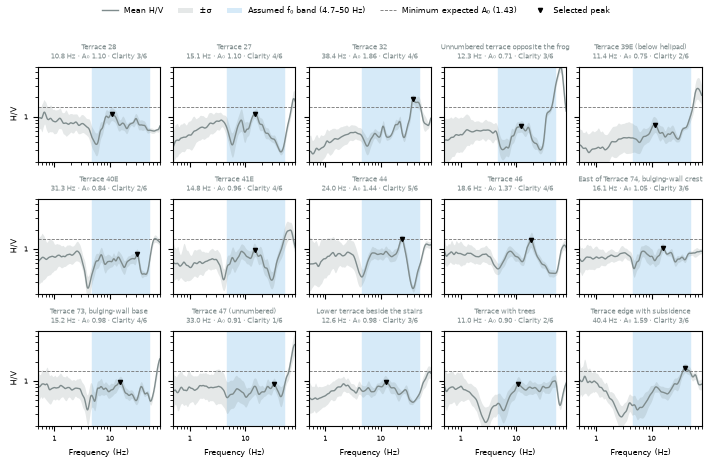

In [35]:
CLASS_COLORS = {'Compatible con relleno sobre roca': '#1e8449', 'Indicio débil': '#7f8c8d',
                'Sin contraste detectable en la banda': '#7f8c8d'}
SITE_NAMES_EN = {
    'Terraza 28': 'Terrace 28',
    'Terraza 27': 'Terrace 27',
    'Terraza 32': 'Terrace 32',
    'Terraza sin número frente a la rana': 'Unnumbered terrace opposite the frog',
    'Terraza 39E (abajo helipuerto)': 'Terrace 39E (below helipad)',
    'Terraza 40E': 'Terrace 40E',
    'Terraza 41E': 'Terrace 41E',
    'Terraza 44': 'Terrace 44',
    'Terraza 46': 'Terrace 46',
    'Exterior al este de Terraza 74, corona muro barrigón': 'East of Terrace 74, bulging-wall crest',
    'Terraza 73, base muro barrigón': 'Terrace 73, bulging-wall base',
    'Terraza 47 (sin número)': 'Terrace 47 (unnumbered)',
    'Terraza abajo, al lado de escalera': 'Lower terrace beside the stairs',
    'Terraza con árboles': 'Terrace with trees',
    'Borde de terraza con subsidencia': 'Terrace edge with subsidence',
}
n = len(table); ncols = 5; nrows = int(np.ceil(n / ncols))
with plt.rc_context({'font.size': 6, 'xtick.labelsize': 5, 'ytick.labelsize': 5}):
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.0, 1.45 * nrows + 0.5), sharex=True, sharey=True, layout='constrained')
    for ax, (_, r) in zip(axes.flat, table.iterrows()):
        f, mean, std = curves[r['Lugar (bitácora)']]
        color = CLASS_COLORS[r['Clasificación']]
        ax.axvspan(F_LO, F_HI, color='#d6eaf8', zorder=0)
        ax.fill_between(f, mean / np.exp(std), mean * np.exp(std), color=color, alpha=0.2, lw=0)
        ax.plot(f, mean, color=color, lw=1.0)
        ax.axhline(A0_MIN_EXPECTED, color='0.45', lw=0.6, ls='--')
        ax.plot(r['f0_banda_Hz'], r['A0_banda'], 'v', color='k', ms=3)
        if np.isfinite(r['Altura_muro_m']):
            ax.axvspan(VS_FILL[0] / (4 * r['Altura_muro_m']), VS_FILL[2] / (4 * r['Altura_muro_m']),
                       color='none', hatch='///', edgecolor='#2471a3', lw=0)
        site_name = SITE_NAMES_EN[r['Lugar (bitácora)']]
        ax.set_title(f"{site_name}\n{r['f0_banda_Hz']:.1f} Hz · A₀ {r['A0_banda']:.2f} · Clarity {r['Claridad']}/6",
                     fontsize=5.2, color=color)
        ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(0.5, 80); ax.set_ylim(0.2, 6)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:g}'))
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:g}'))
        ax.yaxis.set_minor_formatter(plt.NullFormatter())
    for ax in axes.flat[n:]:
        ax.axis('off')
    for ax in axes[-1]:
        ax.set_xlabel('Frequency (Hz)')
    for ax in axes[:, 0]:
        ax.set_ylabel('H/V')
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    panel_handles = [
        Line2D([], [], color='#7f8c8d', lw=1.0, label='Mean H/V'),
        Patch(facecolor='#7f8c8d', alpha=0.2, label='±σ'),
        Patch(facecolor='#d6eaf8', label=f'Assumed f₀ band ({F_LO:.1f}–{F_HI:.0f} Hz)'),
        Line2D([], [], color='0.45', lw=0.6, ls='--', label=f'Minimum expected A₀ ({A0_MIN_EXPECTED:.2f})'),
        Line2D([], [], color='k', marker='v', ls='None', ms=3, label='Selected peak'),
    ]
    fig.legend(handles=panel_handles, loc='outside upper center', ncol=5, frameon=False, fontsize=5.5)
    fig.get_layout_engine().set(rect=(0.0, 0.06, 1.0, 0.92))
    #fig.text(0.5, 0.008, 'Figure 1. Shading marks the assumed resonance-frequency band; the dashed line marks the minimum amplitude expected for the assumed impedance contrast.',
    #         ha='center', va='bottom', fontsize=5.5)
    for ext in ('png', 'pdf', 'svg'):
        fig.savefig(OUTPUT_DIR / f'constrained_hvsr_panels.{ext}', dpi=300, bbox_inches='tight')
    plt.show()

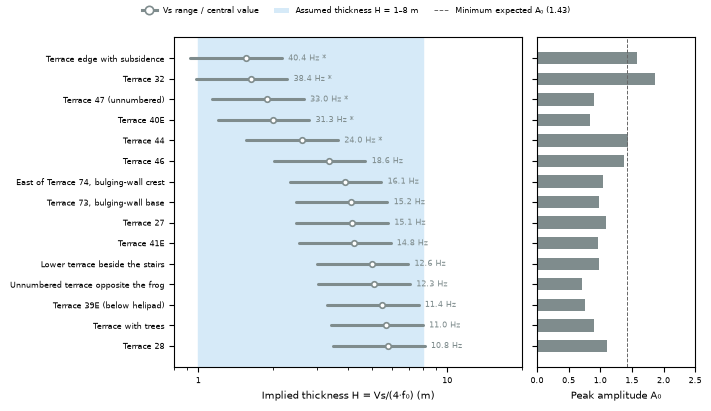

In [36]:
order = table.sort_values('H_Vs250_m').reset_index(drop=True)
with plt.rc_context({'font.size': 7, 'xtick.labelsize': 6, 'ytick.labelsize': 6, 'legend.fontsize': 6}):
    fig, (ax, axa) = plt.subplots(1, 2, figsize=(7.0, 4.3), sharey=True, layout='constrained',
                                  gridspec_kw={'width_ratios': [2.2, 1]})
    y = np.arange(len(order))
    ax.axvspan(*H_RANGE, color='#d6eaf8', zorder=0, label='H supuesto 1–8 m')
    for k, r in order.iterrows():
        color = CLASS_COLORS[r['Clasificación']]
        ax.plot([r['H_Vs150_m'], r['H_Vs350_m']], [k, k], color=color, lw=2.2, solid_capstyle='round')
        ax.plot(r['H_Vs250_m'], k, 'o', color='white', mec=color, mew=1.2, ms=4)
        ax.text(r['H_Vs350_m'] * 1.06, k, f"{r['f0_banda_Hz']:.1f} Hz" + ('' if r['Cobertura_SESAME'] else ' *'),
                va='center', fontsize=5.5, color=color)
        if np.isfinite(r['Altura_muro_m']):
            ax.plot(r['Altura_muro_m'], k, 'D', color='#2471a3', ms=3.5)
        axa.barh(k, r['A0_banda'], color=color, height=0.6)
    ax.set_xscale('log'); ax.set_xlim(0.8, 20)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:g}'))
    ax.set_yticks(y); ax.set_yticklabels(
        [SITE_NAMES_EN[name] for name in order['Lugar (bitácora)']], fontsize=5.5)
    ax.invert_yaxis()
    ax.set_xlabel('Implied thickness H = Vs/(4·f₀) (m)')
    axa.axvline(A0_MIN_EXPECTED, color='0.4', ls='--', lw=0.7, label=f'A0 mín. esperado ({A0_MIN_EXPECTED:.1f})')
    axa.set_xlim(0, 2.5); axa.set_xlabel('Peak amplitude A₀')
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    handles = [
        #Line2D([], [], color='#1e8449', lw=2.2),#, label='Compatible with fill over rock'
        #Line2D([], [], color='#7f8c8d', lw=2.2),#, label='No detectable contrast / weak indication'
        Line2D([], [], color='#7f8c8d', lw=2.2, marker='o', markerfacecolor='white',
               markeredgewidth=1.2, label='Vs range / central value'),
        Patch(facecolor='#d6eaf8', label='Assumed thickness H = 1–8 m'),
        Line2D([], [], color='0.4', lw=0.7, ls='--', label=f'Minimum expected A₀ ({A0_MIN_EXPECTED:.2f})'),
    ]
    fig.legend(handles=handles, loc='outside upper center', ncol=3, frameon=False, fontsize=5.5)
    fig.get_layout_engine().set(rect=(0.0, 0.07, 1.0, 0.92))
    # fig.text(0.5, 0.008, 'Figure 2. Bars show implied thickness for Vs = 150–350 m/s; open circles mark Vs = 250 m/s. Asterisks indicate incomplete SESAME frequency coverage.',
    #          ha='center', va='bottom', fontsize=5.5)
    for ext in ('png', 'pdf', 'svg'):
        fig.savefig(OUTPUT_DIR / f'constrained_f0_thickness.{ext}', dpi=300, bbox_inches='tight')
    plt.show()

## Interpretación con los supuestos

1. **Ningún sitio muestra la resonancia esperada de un relleno de 1–8 m sobre roca con Vs ≥ 500 m/s.** Dentro de 4.7–50 Hz no hay ningún A0 ≥ 2. En 11 de 15 sitios el A0 está por debajo de 1.1, por debajo del contraste mínimo de 1.4 que implican los supuestos. La explicación más simple es una de dos: el relleno tiene una rigidez parecida a la de la roca de abajo (contraste de Vs menor que 1.4), o es demasiado delgado (menos de 1 m) para resonar dentro de la banda medible.
2. **La Terraza 44 es el único indicio, y es débil.** Tiene f0 ≈ 24 Hz, A0 ≈ 1.44, claridad 5/6 y f0 estable (3 % entre variantes). Implicaría H ≈ 1.6–3.6 m (≈2.6 m con Vs = 250). Como 4·f0 está por encima de 80 Hz, la cobertura SESAME es incompleta. Es la mejor candidata para contrastar con la altura real de su muro.
3. **Terraza 32 y borde con subsidencia:** tienen picos de 38–40 Hz con A0 de 1.6–1.9, que equivalen a H ≈ 1–2.3 m. Sin embargo, en la Terraza 32 el f0 cambia hasta 25 % según el perfil, y ninguno de los dos tiene cobertura completa. Pueden ser rellenos muy delgados o el acople del sensor.
4. **Terraza 46 (18.6 Hz, A0 1.37, H ≈ 3.4 m):** queda justo por debajo del umbral. Es el pico con mejor cobertura (f0 < 20 Hz) entre los que tienen algo de amplitud.
5. **Los picos de ≈1 Hz (subsidencia y base del muro barrigón) no se pueden explicar con estos supuestos,** porque implicarían más de 37 m de relleno. Si son reales, se deben a estructura más profunda (coluvión potente o saprolito sobre roca sana) o a fuentes de ruido.

### Cómo afinar
- Completar `WALL_HEIGHT_M` con la altura medida del muro. El notebook calcula la banda de f0 predicha para cada sitio y marca si el f0 observado es consistente.
- Si se dispone de Vs medido (MASW o sísmica de refracción en una terraza), reemplazar el rango 150–350 m/s por el valor medido para reducir la incertidumbre de H a la mitad o menos.
- Para validar picos por encima de 20 Hz se necesita un muestreo de al menos 500 Hz, porque así 4·f0 queda por debajo de Nyquist.